In [62]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [63]:
df=pd.read_csv('marketing_campaign.csv',sep='\t')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [65]:
df['Age']=2026-df['Year_Birth']

In [66]:
mnt_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df['TotalSpend'] = df[mnt_cols].sum(axis=1)
df['TotalPurchases'] = df[['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)
df['TotalAccepted'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)

# Drop columns
drop_cols = ['ID','Dt_Customer','Z_CostContact','Z_Revenue','Year_Birth','Year_Birth']
df.drop(columns=drop_cols, inplace=True)

# Drop missing
df.dropna(inplace=True)

# One-hot encode categoricals
df = pd.get_dummies(df, columns=['Education','Marital_Status'], drop_first=False,dtype=int)

In [67]:
df

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,0,0,1,0,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,0,0,1,0,0,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,0,0,0,0,1,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,0,0,0,0,1,0,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,0,0,0,1,0,0,0,0
2236,64014.0,2,1,56,406,0,30,0,0,8,...,0,1,0,0,0,0,0,1,0,0
2237,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,0,0,0
2238,69245.0,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,0,0,1,0,0


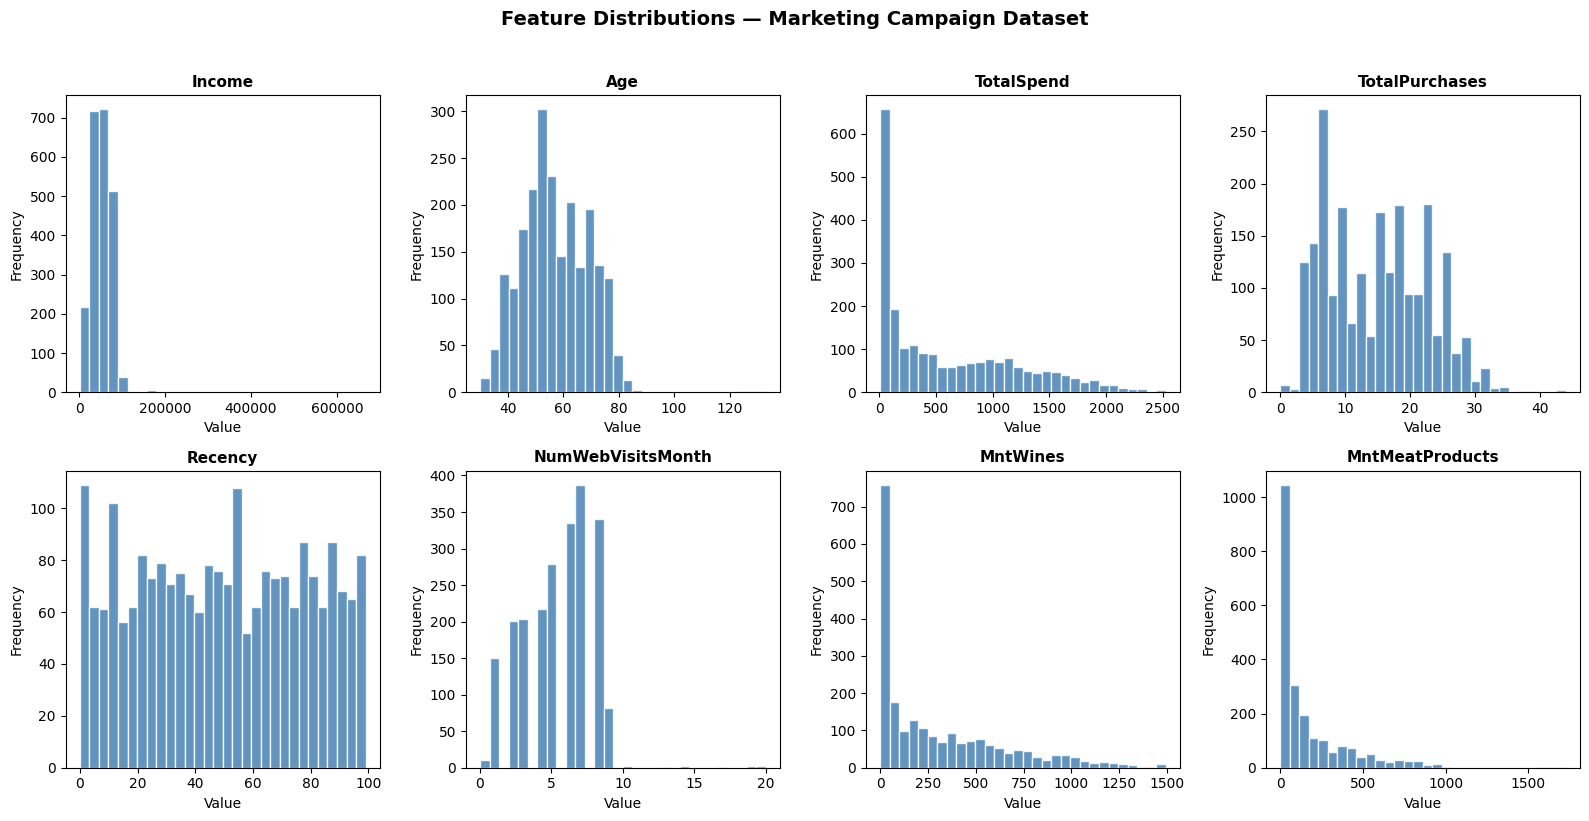

EDA Plot 1 saved.


In [68]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
eda_cols = ['Income','Age','TotalSpend','TotalPurchases','Recency',
            'NumWebVisitsMonth','MntWines','MntMeatProducts']

for ax, col in zip(axes.flatten(), eda_cols):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

fig.suptitle('Feature Distributions — Marketing Campaign Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print("EDA Plot 1 saved.")


In [69]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [70]:
# ── 5. PCA for 2D visualization ───────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.3f}")

Explained variance ratio: PC1=0.215, PC2=0.069
Total variance explained by 2 PCs: 0.284


In [71]:
dict={'pc1':pca.explained_variance_ratio_[0],'pc2':pca.explained_variance_ratio_[1]}

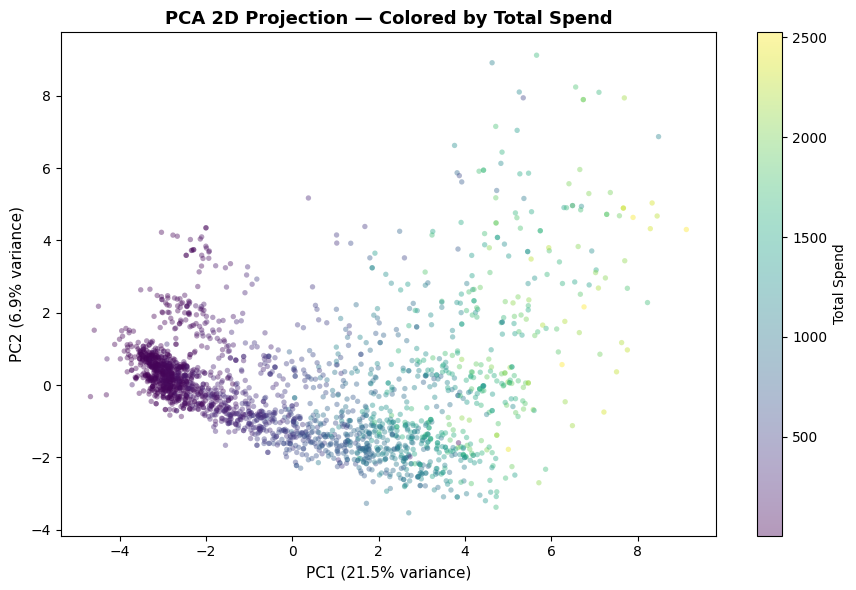

EDA Plot 3 saved.


In [72]:
# ── EDA Plot 3: PCA scatter plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=15, c=df['TotalSpend'],
                cmap='viridis', edgecolors='none')
plt.colorbar(sc, ax=ax, label='Total Spend')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA 2D Projection — Colored by Total Spend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_pca.png', bbox_inches='tight')
plt.show()
print("EDA Plot 3 saved.")

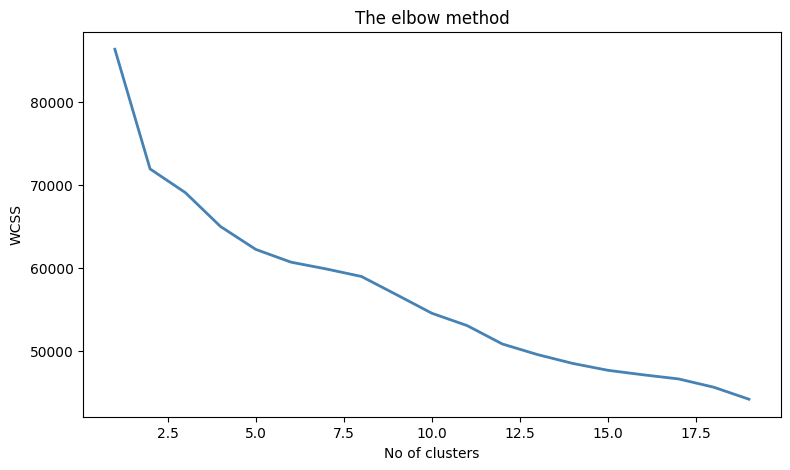

In [73]:
wcss=[]
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(1,20):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.plot(range(1,20),wcss, color='steelblue', linewidth=2, markersize=7)
plt.title('The elbow method')
plt.xlabel('No of clusters')
plt.ylabel('WCSS')
plt.show()

In [74]:
kmeans1=KMeans(n_clusters=4,init='k-means++',random_state=42)
y_kmeans=kmeans1.fit_predict(X_scaled)

In [75]:
X_pca

array([[ 4.39387086, -0.16299618],
       [-2.82617371,  0.05314276],
       [ 1.63349882, -1.49877822],
       ...,
       [ 1.96693319,  0.59458973],
       [ 1.836371  , -1.88124337],
       [-1.67956542,  1.21328944]], shape=(2216, 2))

Class distribution:
0    1046
1     645
2      30
3     495
Name: count, dtype: int64


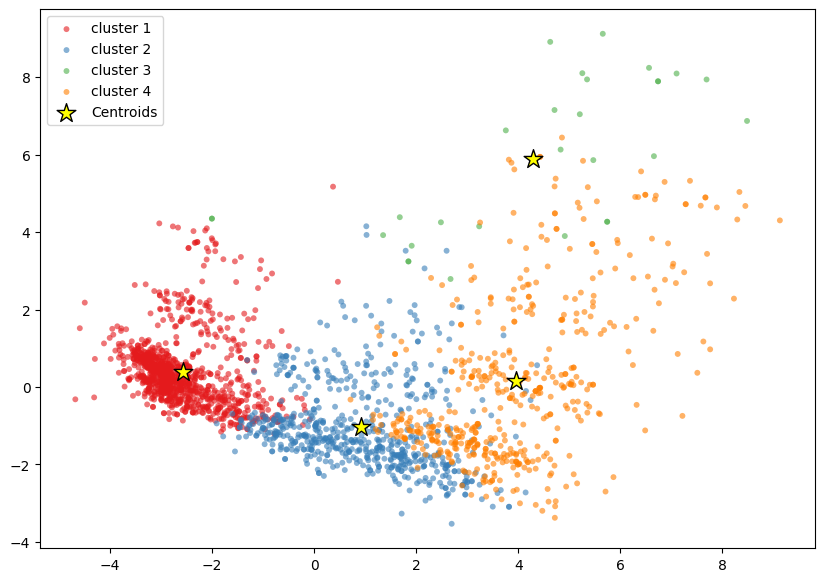

In [78]:
print('Class distribution:')
print(pd.Series(y_kmeans).value_counts().sort_index())
fig, ax = plt.subplots(figsize=(10, 7))
plt.scatter(X_pca[y_kmeans==0,0],X_pca[y_kmeans==0,1],c='#e41a1c',label='cluster 1',s=18, alpha=0.6,edgecolors='none')
plt.scatter(X_pca[y_kmeans==1,0],X_pca[y_kmeans==1,1],c='#377eb8',label='cluster 2',s=18, alpha=0.6,edgecolors='none')
plt.scatter(X_pca[y_kmeans==2,0],X_pca[y_kmeans==2,1],c='#4daf4a',label='cluster 3',s=18, alpha=0.6,edgecolors='none')
plt.scatter(X_pca[y_kmeans==3,0],X_pca[y_kmeans==3,1],c='#ff7f00',label='cluster 4',s=18, alpha=0.6,edgecolors='none')

centroids_pca = pca.transform(kmeans1.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=200, c='yellow', edgecolors='black', marker='*', label='Centroids')
plt.legend()
plt.show()